In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [7]:
#This code gets a disease hierarcy from DOID using OLS web service
#see https://www.ebi.ac.uk/ols4/swagger-ui/index.html#/
#look for ## to modify the code below

import requests
import pandas as pd

##replace the following file_name with your own
file_name='/content/gdrive/MyDrive/Yale/term_doid_icd2.txt'

cols = ['Group', 'Term', 'DOID', 'ICD10Code']
data=[]

##add one more disease to the following dict (I chose liver disease)
ids={'Kidney Disease':'DOID_557','Lung Disease':'DOID_850', 'Liver Disease': 'DOID_409'} #kidney, lung disease, liver disease
ont='doid'
root_url='http%253A%252F%252Fpurl.obolibrary.org%252Fobo%252F'
base_url='https://www.ebi.ac.uk/ols4/api/ontologies/'+ont+'/terms/'

for id in ids.keys():
  root_class=root_url+ids[id]
  search_url=base_url+root_class+'/hierarchicalDescendants?'
  print(search_url)
  flag=1
  page_size=100
  page_curr=0
  while flag==1:
    PARAMS = {'lang':'en','size':page_size,'page':page_curr}
    #sending get request and saving the response as response object
    r = requests.get(url = search_url, params = PARAMS)
    #extracting data in json format
    #find entities from ontologies
    data2 = r.json()
    terms=data2['_embedded']['terms']
    total_pages=data2['page']['totalPages']
    for t in terms:
      if 'annotation' in t.keys():
        if 'database_cross_reference' in t['annotation']:
          for d in t['annotation']['database_cross_reference']:
            if 'ICD10CM' in d:
              lbl=t['label']
              iri=t['iri']
              icd10_code=d.split(':')[1]
              #print(lbl,iri,icd10_code)
              data.append((id,lbl,iri,icd10_code))
    page_curr=page_curr+1
    if page_curr==total_pages: #total_pages or max
      flag=0
    else:
      flag=1
  #endwhile
#print(data)
df = pd.DataFrame(data, columns=cols)

f = open(file_name, 'w')
df.to_csv(f, sep='\t', encoding='utf-8', index=False, header=True)

f.close()
print('Done!')


https://www.ebi.ac.uk/ols4/api/ontologies/doid/terms/http%253A%252F%252Fpurl.obolibrary.org%252Fobo%252FDOID_557/hierarchicalDescendants?
https://www.ebi.ac.uk/ols4/api/ontologies/doid/terms/http%253A%252F%252Fpurl.obolibrary.org%252Fobo%252FDOID_850/hierarchicalDescendants?
https://www.ebi.ac.uk/ols4/api/ontologies/doid/terms/http%253A%252F%252Fpurl.obolibrary.org%252Fobo%252FDOID_409/hierarchicalDescendants?
Done!


---- Disease Group and Unique Subjects ----
     DiseaseGroup  unique_subjects
0  Kidney Disease             1340
1    Lung Disease             1050
2   Liver Disease              921
---- Disease Group and Unique Subjects by Gender and Race----
       DiseaseGroup gender                          race  unique_subjects
0    Kidney Disease      F                         WHITE              446
1    Kidney Disease      M                         WHITE              275
2    Kidney Disease      F        BLACK/AFRICAN AMERICAN              135
3    Kidney Disease      M        BLACK/AFRICAN AMERICAN               47
4    Kidney Disease      F                         OTHER               41
..              ...    ...                           ...              ...
163    Lung Disease      M                ASIAN - KOREAN                1
164    Lung Disease      M  HISPANIC/LATINO - GUATEMALAN                1
165    Lung Disease      F   HISPANIC/LATINO - COLUMBIAN                1
166    Lung Di

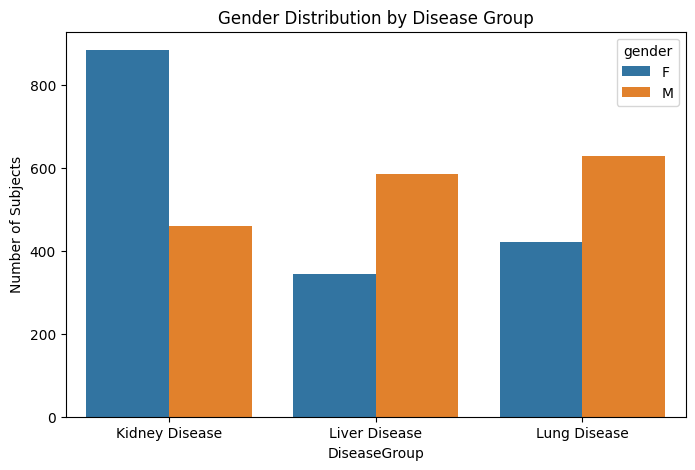

---- Gender Counts by Disease Group ----


,DiseaseGroup,gender,unique_subjects
0,Kidney Disease,F,884
5,Lung Disease,M,628
3,Liver Disease,M,585
1,Kidney Disease,M,460
4,Lung Disease,F,422
2,Liver Disease,F,343


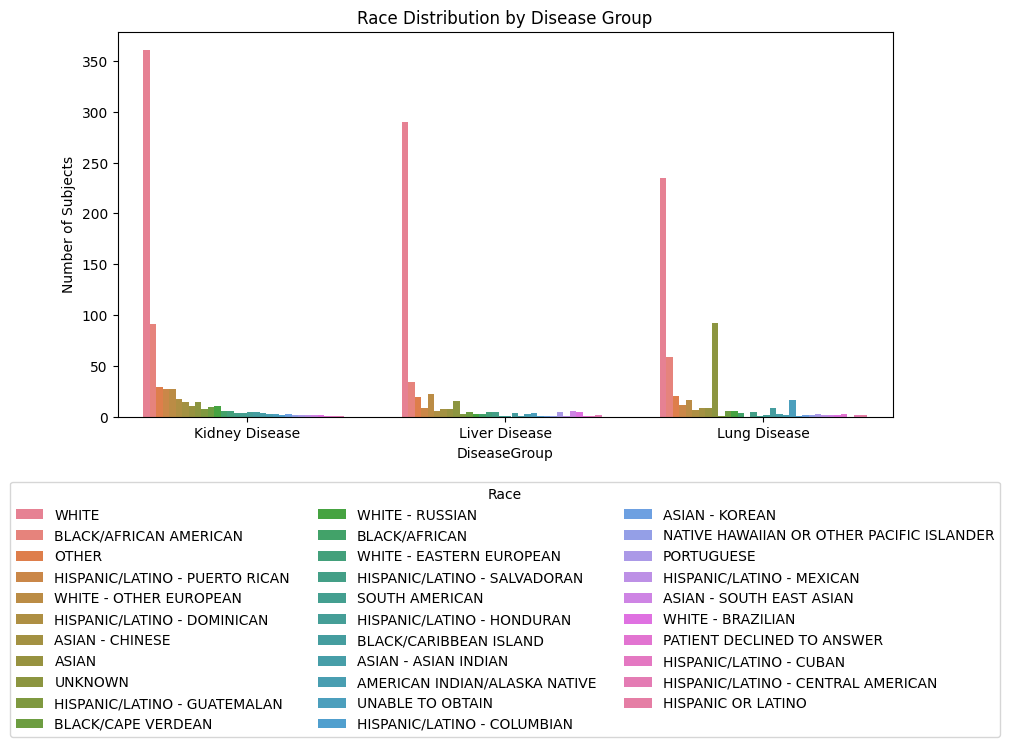

---- Race Counts by Disease Group ----


,DiseaseGroup,race,unique_subjects
26,Kidney Disease,WHITE,721
57,Liver Disease,WHITE,579
88,Lung Disease,WHITE,470
87,Lung Disease,UNKNOWN,184
7,Kidney Disease,BLACK/AFRICAN AMERICAN,182
69,Lung Disease,BLACK/AFRICAN AMERICAN,118
38,Liver Disease,BLACK/AFRICAN AMERICAN,68
20,Kidney Disease,OTHER,58
29,Kidney Disease,WHITE - OTHER EUROPEAN,54
17,Kidney Disease,HISPANIC/LATINO - PUERTO RICAN,54


In [25]:
##After the file has been uploaded to BigQuery as a table. Then write python code to do the following.
##Connect to BigQuery to issue a query to join this table with the "physionet-data.mimiciv_hosp.diagnoses_icd"
##table to count the number of unique subjects for each disease group
# !pip install --upgrade google-cloud-bigquery pandas matplotlib seaborn

from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import auth
auth.authenticate_user()

client = bigquery.Client(project="cbb6380-final-project")

query1 = """
WITH disease_icd AS (
  SELECT ICD10Code, `Group` AS DiseaseGroup
  FROM `cbb6380-final-project.homework_4.term_doid_icd2`
)
SELECT
  d.DiseaseGroup,
  COUNT(DISTINCT diag.subject_id) AS unique_subjects
FROM
  `physionet-data.mimiciv_3_1_hosp.diagnoses_icd` diag
JOIN
  disease_icd d
ON
  diag.icd_code = d.ICD10Code
GROUP BY
  d.DiseaseGroup
ORDER BY
  unique_subjects DESC
"""

df_counts = client.query(query1).to_dataframe()
print("---- Disease Group and Unique Subjects ----")
print(df_counts)

##If the join query works, expand it to join the patients and admissions tables.
##Use the results of the expanded query to show some demographic distributions (e.g., gender and race) for each disease group
query2 = """
WITH disease_icd AS (
  SELECT ICD10Code, `Group` AS DiseaseGroup
  FROM `cbb6380-final-project.homework_4.term_doid_icd2`
)
SELECT
  d.DiseaseGroup,
  p.gender,
  a.race,
  COUNT(DISTINCT p.subject_id) AS unique_subjects
FROM
  `physionet-data.mimiciv_3_1_hosp.diagnoses_icd` diag
JOIN
  disease_icd d
ON
  diag.icd_code = d.ICD10Code
JOIN
  `physionet-data.mimiciv_3_1_hosp.patients` p
ON
  diag.subject_id = p.subject_id
JOIN
  `physionet-data.mimiciv_3_1_hosp.admissions` a
ON
  diag.hadm_id = a.hadm_id
GROUP BY
  d.DiseaseGroup,
  p.gender,
  a.race
ORDER BY
  d.DiseaseGroup, unique_subjects DESC
"""
df_demo = client.query(query2).to_dataframe()
print("---- Disease Group and Unique Subjects by Gender and Race----")
print(df_demo)

##Show the distributions graphically (e.g., barchart/piechart/etc) in this python notebook
# Gender distribution by disease group
df_gender = df_demo.groupby(['DiseaseGroup','gender'], as_index = False)['unique_subjects'].sum()
plt.figure(figsize = (8,5))
sns.barplot(data = df_gender, x = 'DiseaseGroup', y = 'unique_subjects', hue = 'gender', errorbar = None)
plt.title('Gender Distribution by Disease Group')
plt.ylabel('Number of Subjects')
plt.show()
print("---- Gender Counts by Disease Group ----")
df_gender = df_gender.sort_values(by = 'unique_subjects', ascending = False)
display(df_gender)

# Race distribution by disease group
df_race = df_demo.groupby(['DiseaseGroup','race'], as_index = False)['unique_subjects'].sum()
plt.figure(figsize = (10,5))
sns.barplot(data = df_demo, x = 'DiseaseGroup', y = 'unique_subjects', hue = 'race', errorbar = None)
plt.title('Race Distribution by Disease Group')
plt.ylabel('Number of Subjects')
plt.legend(title = 'Race', loc = 'upper center', bbox_to_anchor = (0.5, -0.15), ncol = 3)
plt.show()
print("---- Race Counts by Disease Group ----")
df_race = df_race.sort_values(by = 'unique_subjects', ascending = False)
df_race.head(20)